In [1]:
import numpy as np
from collections import Counter
import random
import pandas as pd

In [2]:
combinations = {
    (1,): 100, (5,): 50, 
    3 * (1,): 1000, 3 * (2,): 200, 3 * (3,): 300, 3 * (4,): 400, 3 * (5,): 500, 3 * (6,): 600,
    4 * (1,): 2*1000, 4 * (2,): 2*200, 4 * (3,): 2*300, 4 * (4,): 2*400, 4 * (5,): 2*500, 4 * (6,): 2*600,
    5 * (1,): 4*1000, 5 * (2,): 4*200, 5 * (3,): 4*300, 5 * (4,): 4*400, 5 * (5,): 4*500, 5 * (6,): 4*600,
    6 * (1,): 8*1000, 6 * (2,): 8*200, 6 * (3,): 8*300, 6 * (4,): 8*400, 6 * (5,): 8*500, 6 * (6,): 8*600,
    (1, 2, 3, 4, 5, 6): 1500, (1, 2, 3, 4, 5): 500, (2, 3, 4, 5, 6): 750
}

def find_scores(dice_counts):
    results = []

    def backtrack(current_counts, current_path, current_score, used_count):
        # Если в пути что-то есть, сохраняем это как вариант
        if current_path:
            results.append((current_path, current_score, 6 - used_count))
        
        # Перебираем все возможные комбинации из словаря
        for combo, points in combinations.items():
            combo_counts = Counter(combo)
            # Проверяем, можно ли взять эту комбинацию
            if all(current_counts[val] >= count for val, count in combo_counts.items()):
                # Уменьшаем счетчик костей
                new_counts = current_counts - combo_counts
                # Рекурсивно ищем дальше, передавая отсортированный путь для избежания повторов
                new_path = tuple(sorted(current_path + (combo,)))
                backtrack(new_counts, new_path, current_score + points, used_count + len(combo))

    backtrack(dice_counts, (), 0, 0)
    return set(results) # Убираем дубликаты


In [3]:
# Генерируем 6 бросков
roll = [random.randint(1, 6) for _ in range(6)]
print(f"Выпало: {tuple(roll)}")

all_found = find_scores(Counter(roll))

# Вывод результатов
for path, total_score, remaining in sorted(all_found, key=lambda x: len(x[0])):
    parts = [f"{c}: {combinations[c]}" for c in path]
    line = ", ".join(parts)
    if len(path) > 1:
        print(f"{line} | сумма: {total_score} | осталось {remaining} костей")
    else:
        print(f"{line} | осталось {remaining} костей")

Выпало: (6, 3, 3, 3, 1, 1)
(3, 3, 3): 300 | осталось 3 костей
(1,): 100 | осталось 5 костей
(1,): 100, (1,): 100 | сумма: 200 | осталось 4 костей
(1,): 100, (3, 3, 3): 300 | сумма: 400 | осталось 2 костей
(1,): 100, (1,): 100, (3, 3, 3): 300 | сумма: 500 | осталось 1 костей


In [4]:
import itertools
from collections import Counter

# Базовый словарь (из предыдущего шага)
base_combinations = {
    (1,): 100, (5,): 50, 
    (1,1,1): 1000, (2,2,2): 200, (3,3,3): 300, (4,4,4): 400, (5,5,5): 500, (6,6,6): 600,
    (1,1,1,1): 2000, (2,2,2,2): 400, (3,3,3,3): 600, (4,4,4,4): 800, (5,5,5,5): 1000, (6,6,6,6): 1200,
    (1,1,1,1,1): 4000, (2,2,2,2,2): 800, (3,3,3,3,3): 1200, (4,4,4,4,4): 1600, (5,5,5,5,5): 2000, (6,6,6,6,6): 2400,
    (1,1,1,1,1,1): 8000, (2,2,2,2,2,2): 1600, (3,3,3,3,3,3): 2400, (4,4,4,4,4,4): 3200, (5,5,5,5,5,5): 4000, (6,6,6,6,6,6): 4800,
    (1,2,3,4,5,6): 1500, (1,2,3,4,5): 500, (2,3,4,5,6): 750
}

def get_all_combinations_sum(base_dict):
    """Создает расширенный словарь всех сочетаний комбинаций."""
    all_combos = {}
    combos_list = list(base_dict.keys())
    
    # Перебираем сочетания от 1 до 6 элементов (макс. количество костей)
    for r in range(1, 7):
        for combo_set in itertools.combinations_with_replacement(combos_list, r):
            # Проверяем, не превышает ли общее кол-во костей 6
            total_dice = sum(len(c) for c in combo_set)
            if total_dice <= 6:
                # Сортируем кортеж кортежей, чтобы порядок не имел значения
                sorted_key = tuple(sorted(combo_set))
                total_points = sum(base_dict[c] for c in combo_set)
                all_combos[sorted_key] = total_points
    return all_combos

def calculate_probabilities(num_dice):
    """Считает вероятность выпадения каждой комбинации очков для N костей."""
    total_outcomes = 6 ** num_dice
    # Словарь для подсчета частоты выпадения сумм очков
    score_frequencies = Counter()
    
    # Генерируем все возможные исходы броска n костей
    for roll in itertools.product(range(1, 7), repeat=num_dice):
        # Для каждого броска ищем лучший набор очков
        # (Упрощенно: ищем максимальную сумму из доступных комбинаций)
        roll_counts = Counter(roll)
        max_score = 0
        
        # Проверяем базовые комбинации, которые влезают в этот бросок
        for combo, points in base_combinations.items():
            if len(combo) <= num_dice:
                combo_counts = Counter(combo)
                if all(roll_counts[v] >= c for v, c in combo_counts.items()):
                    # Здесь можно усложнить логику до поиска всех вариантов,
                    # но для вероятностей обычно важен факт наличия очков.
                    if points > max_score: max_score = points
        
        score_frequencies[max_score] += 1
    
    # Превращаем частоты в вероятности
    probabilities = {score: count / total_outcomes for score, count in score_frequencies.items()}
    return probabilities

n = 6
# Вызов функций
extended_dict = get_all_combinations_sum(base_combinations)
probs = calculate_probabilities(n) # Пример для 2 костей

print(f"Пример расширенного словаря (фрагмент): {list(extended_dict.items())[:3]}")
print(f"Вероятности очков для {n} костей: {probs}")

expected_value = sum(score * prob for score, prob in probs.items())

print(f"M = {expected_value}")

Пример расширенного словаря (фрагмент): [(((1,),), 100), (((5,),), 50), (((1, 1, 1),), 1000)]
Вероятности очков для 6 костей: {8000: 2.143347050754458e-05, 4000: 0.000664437585733882, 2000: 0.008680555555555556, 1000: 0.06162122770919067, 400: 0.060335219478737996, 200: 0.051440329218107, 100: 0.4050925925925926, 300: 0.05186899862825789, 500: 0.09130658436213991, 600: 0.06119255829903978, 800: 0.008680555555555556, 1200: 0.008680555555555556, 1500: 0.015432098765432098, 1600: 0.000664437585733882, 2400: 0.000664437585733882, 0: 0.030864197530864196, 50: 0.10416666666666667, 750: 0.038580246913580245, 3200: 2.143347050754458e-05, 4800: 2.143347050754458e-05}
M = 332.15449245541834


In [5]:
probs1 = calculate_probabilities(1)
probs2 = calculate_probabilities(2)
probs3 = calculate_probabilities(3)
probs4 = calculate_probabilities(4)
probs5 = calculate_probabilities(5)
probs6 = calculate_probabilities(6)

In [6]:
probs1

{100: 0.16666666666666666, 0: 0.6666666666666666, 50: 0.16666666666666666}

In [7]:
expected_value1 = sum(score * prob for score, prob in probs1.items())
expected_value2 = sum(score * prob for score, prob in probs2.items())
expected_value3 = sum(score * prob for score, prob in probs3.items())
expected_value4 = sum(score * prob for score, prob in probs4.items())
expected_value5 = sum(score * prob for score, prob in probs5.items())
expected_value6 = sum(score * prob for score, prob in probs6.items())

In [8]:
P0_1 = probs1[0]
P0_2 = probs2[0]
P0_3 = probs3[0]
P0_4 = probs4[0]
P0_5 = probs5[0]
P0_6 = probs6[0]


In [9]:
print(P0_1)
print(P0_2)
print(P0_3)
print(P0_4)
print(P0_5)
print(P0_6)

0.6666666666666666
0.4444444444444444
0.2777777777777778
0.1574074074074074
0.07716049382716049
0.030864197530864196


In [10]:
class Player():
    def __init__(self, w=[random.random() for _ in range(16)]) -> None:
        self.w1 = w[0]
        self.w2 = w[1]
        self.w3 = w[2]
        self.w4 = w[3]
        self.w5 = w[4]
        self.w6 = w[5]
        self.w7 = w[6]
        self.w8 = w[7]
        self.w9 = w[8]
        self.w10 = w[9]
        self.w11 = w[10]
        self.w12 = w[11]
        self.w13 = w[12]
        self.w14 = w[13]
        self.w15 = w[14]
        self.w16 = w[15]

        self.W = w

        self.path = []

    def get_w(self):
        return self.W

    def make_decision(self, total, you_have, opponent_have, dice_count, round_have, comb_list):
        choose = []
        choose.append(("skip", self.w6 * (self.w1*total + self.w2*you_have + self.w3*opponent_have + self.w4*dice_count + self.w5*round_have + sum([self.w7*s + self.w8*d for s,d in comb_list]))))
        for s, d in comb_list:
            choose.append(((s, d), self.w16 * (self.w9*total + self.w10*you_have + self.w11*opponent_have + self.w12*dice_count + self.w13*round_have + self.w14*s + self.w15*d)))

        return max(choose, key=lambda x: x[1])

class Player2():
    def __init__(self, w=[random.random() for _ in range(16)]) -> None:
        self.w1 = w[0]
        self.w2 = w[1]
        self.w3 = w[2]
        self.w4 = w[3]
        self.w5 = w[4]
        self.w6 = w[5]
        self.w7 = w[6]
        self.w8 = w[7]
        self.w9 = w[8]
        self.w10 = w[9]
        self.w11 = w[10]
        self.w12 = w[11]
        self.w13 = w[12]
        self.w14 = w[13]
        self.w15 = w[14]
        self.w16 = w[15]

        self.W = w

        self.path = []

    def get_w(self):
        return self.W

    def make_decision(self, total, you_have, opponent_have, dice_count, round_have, comb_list):
        left_to_you = total - you_have
        left_to_opponent = total - opponent_have
        deff_u_and_op = you_have - opponent_have 


        choose = []
        choose.append(("skip", self.w6 * (self.w1*total + self.w2*you_have + self.w3*opponent_have + self.w4*dice_count + self.w5*round_have + sum([self.w7*s + self.w8*d for s,d in comb_list]))))
        for s, d in comb_list:
            choose.append(((s, d), self.w16 * (self.w9*total + self.w10*you_have + self.w11*opponent_have + self.w12*dice_count + self.w13*round_have + self.w14*s + self.w15*d)))

        return max(choose, key=lambda x: x[1])

In [12]:
def turn(player: Player, dice_count, total, player_have, opponent_have, round_have):

    roll = [random.randint(1, 6) for _ in range(dice_count)]

    all_found = find_scores(Counter(roll))
    #print(f"all_found: {all_found}")
    comb_list = [(s, 6-d) for _,s,d in all_found]

    player.path.append([total, player_have, opponent_have, dice_count, round_have, comb_list])

    if (len(comb_list) == 0):
        player.path[-1].append("lose")
        return ("lose",)

    decision = player.make_decision(total, player_have, opponent_have, dice_count, round_have, comb_list)

    if (decision[0] == 'skip'):
        player.path[-1].append("skip")
        return "skip", max(comb_list, key=lambda x: x[0])[0]
    else:
        player.path[-1].append(decision[0])
        return decision[0][0], decision[0][1]

def round(player: Player, total, player_have, opponent_have, dice_count, round_have):
    #print(f"\nstart with d: {dice_count} and r: {round_have} ")

    trn = turn(player, dice_count, total, player_have, opponent_have, round_have)
    #print(f"turn decision: {trn}")

    if trn[0] == "lose":
        return 0
    if trn[0] == "skip":
        return trn[1]
    return round(player, total, player_have, opponent_have, dice_count - trn[1], round_have + trn[0])



def game(player1: Player, player2, total, max_rounds=100):
    #print(f"player1_w: {player1.get_w()}")

    player1_have = 0
    player2_have = 0
    rounds = 0

    while (player1_have < total or player2_have < total):
        if rounds >= max_rounds:
            return (True, False) if player1_have > player2_have else (False, True)
        #print("\n------------------------------")
        #print("player1 round")
        player1_have += round(player1, total, player1_have, player2_have, 6, 0)
        if (player1_have >= total):
            return True, False
        #print("\n------------------------------")
        #print("player2 round")
        player2_have += round(player2, total, player2_have, player1_have, 6, 0)
        if (player2_have >= total):
            return False, True
        rounds += 1

def game2(player1: Player, player2, total, max_rounds=100):
    #print(f"player1_w: {player1.get_w()}")

    player1_have = 0
    player2_have = 0
    rounds = 0

    while (player1_have < total or player2_have < total):
        if rounds >= max_rounds:
            return (True, False, rounds) if player1_have > player2_have else (False, True, rounds)
        #print("\n------------------------------")
        #print("player1 round")
        player1_have += round(player1, total, player1_have, player2_have, 6, 0)
        if (player1_have >= total):
            return True, False, rounds
        #print("\n------------------------------")
        #print("player2 round")
        player2_have += round(player2, total, player2_have, player1_have, 6, 0)
        if (player2_have >= total):
            return False, True, rounds
        rounds += 1

In [16]:
def GenAlg(total, genCount, how_many_to_select, init_distribution_of_w=[random.random() for _ in range(16)]):

    number_of_individuals = how_many_to_select * (how_many_to_select + 1)

    #Gen = GenOriginal.copy()

    Gen = [[Player(init_distribution_of_w), 0] for _ in range(number_of_individuals)]

    for gen_i in range(genCount):
        print("\n-------------------")
        print(f"gen: {gen_i+1}")
        for i in range(len(Gen)-1):
            for j in range(i+1, len(Gen)):
                #print(f"game between: {i} and {j}")
                result = game(Gen[i][0], Gen[j][0], total)
                Gen[i][1] += result[0]
                Gen[j][1] += result[1]

        Gen.sort(key=lambda x: x[1])
        print(f"Gen{gen_i+1}: {Gen}")

        if (gen_i == genCount-1):
            break

        winners = [player for player, _ in Gen[-how_many_to_select:]]

        for winner in winners:
            winner.path = []

        winners_w = [np.array(winner.get_w()) for winner in winners]

        K = [np.random.rand(len(winner_w.tolist())) for winner_w in winners_w]

        C_w = []
        for i in range(how_many_to_select-1):
            for j in range(i+1, how_many_to_select):
                C_w.append((1 - K[i]) * winners_w[i] + K[i] * winners_w[j])

        Gen = [[winner, 0] for winner in winners]
        for c_w in C_w:
            Gen.append([Player(c_w), 0])

        n = len(Gen)
        for i in range(n):
            Gen.append([Player(np.array(Gen[i][0].get_w()) + np.random.normal(size=16)), 0])

    return Gen

def GenAlg2(total, genCount, how_many_to_select, init_distribution_of_w=[random.random() for _ in range(16)]):

    #number_of_individuals = how_many_to_select * (how_many_to_select + 1)
    number_of_individuals = 2*how_many_to_select**2


    Gen = [[Player(init_distribution_of_w), 0, 0] for _ in range(number_of_individuals)]

    for gen_i in range(genCount):
        print("\n-------------------")
        print(f"gen: {gen_i+1}")
        for i in range(len(Gen)-1):
            for j in range(i+1, len(Gen)):
                #print(f"game between: {i} and {j}")
                result = game2(Gen[i][0], Gen[j][0], total)
                Gen[i][1] += result[0]
                Gen[j][1] += result[1]
                
                Gen[i][2] = max(Gen[i][2], result[0]*result[2])
                Gen[j][2] = max(Gen[j][2], result[1]*result[2])

        GenWinners = (Gen.copy()).sort(key=lambda x: x[1])
        print(f"Gen{gen_i+1}: {GenWinners}")

        GenSpeedest = (Gen.copy()).sort(key=lambda x: -x[2])
        print(f"Gen{gen_i+1}: {GenSpeedest}")

        if (gen_i == genCount-1):
            break

        winners = [player for player, _ in GenWinners[-how_many_to_select:]]

        for winner in winners:
            winner.path = []

        winners_w = [np.array(winner.get_w()) for winner in winners]

        K = [np.random.rand(len(winner_w.tolist())) for winner_w in winners_w]

        C_w = []
        for i in range(how_many_to_select-1):
            for j in range(i+1, how_many_to_select):
                C_w.append((1 - K[i]) * winners_w[i] + K[i] * winners_w[j])

        Gen = [[winner, 0] for winner in winners]
        for c_w in C_w:
            Gen.append([Player(c_w), 0])

        speedest = [player for player, _ in GenSpeedest[-how_many_to_select:]]

        for speedie in speedest:
            speedie.path = []

        speedest_w = [np.array(speedie.get_w()) for speedie in speedest]

        K = [np.random.rand(len(speedie_w.tolist())) for speedie_w in speedest_w]

        C_w = []
        for i in range(how_many_to_select-1):
            for j in range(i+1, how_many_to_select):
                C_w.append((1 - K[i]) * speedest_w[i] + K[i] * speedest_w[j])

        Gen = [[speedie, 0] for speedie in speedest]
        for c_w in C_w:
            Gen.append([Player(c_w), 0])

        n = len(Gen)
        for i in range(n):
            Gen.append([Player(np.array(Gen[i][0].get_w()) + np.random.normal(size=16)), 0])

    return Gen


In [17]:
brood1_game2 = GenAlg2(4000, 1, 5)
len(brood1_game2)


-------------------
gen: 1
Gen1: None
Gen1: None


50

In [19]:
brood1_game2

[[<__main__.Player at 0x25ae0f0e560>, 0, 0],
 [<__main__.Player at 0x25ae0f0e770>, 1, 100],
 [<__main__.Player at 0x25ae0f0e7d0>, 2, 100],
 [<__main__.Player at 0x25ae0f0e800>, 3, 100],
 [<__main__.Player at 0x25ae0f0e860>, 4, 100],
 [<__main__.Player at 0x25ae0f0e8c0>, 5, 100],
 [<__main__.Player at 0x25ae0f0ebc0>, 6, 100],
 [<__main__.Player at 0x25ae0f0ebf0>, 7, 100],
 [<__main__.Player at 0x25ae0f0ef50>, 8, 100],
 [<__main__.Player at 0x25ae0f0ee60>, 9, 100],
 [<__main__.Player at 0x25ae0f0e290>, 10, 100],
 [<__main__.Player at 0x25ae0f0e230>, 11, 100],
 [<__main__.Player at 0x25ae0f0e110>, 12, 100],
 [<__main__.Player at 0x25ae0f0e710>, 13, 100],
 [<__main__.Player at 0x25ae0f0eef0>, 14, 100],
 [<__main__.Player at 0x25ae0f0ef20>, 15, 100],
 [<__main__.Player at 0x25ae0f0ed10>, 16, 100],
 [<__main__.Player at 0x25ae0f0e5c0>, 17, 100],
 [<__main__.Player at 0x25ae0f0e7a0>, 18, 100],
 [<__main__.Player at 0x25ae0f0e1d0>, 19, 100],
 [<__main__.Player at 0x25ae0f0e1a0>, 20, 100],
 [<_

In [123]:
brood1 = GenAlg(4000, 2, 7)
len(brood1)


-------------------
gen: 1
Gen1: [[<__main__.Player object at 0x0000028BE7FF8B20>, 15], [<__main__.Player object at 0x0000028BE7FF8160>, 20], [<__main__.Player object at 0x0000028BE7FF82B0>, 21], [<__main__.Player object at 0x0000028BE7FF8220>, 21], [<__main__.Player object at 0x0000028BE7FF8A60>, 22], [<__main__.Player object at 0x0000028BE7FF8370>, 22], [<__main__.Player object at 0x0000028BE7FFABC0>, 24], [<__main__.Player object at 0x0000028BE7FF8460>, 24], [<__main__.Player object at 0x0000028BE7FF8250>, 24], [<__main__.Player object at 0x0000028BE7FF8EE0>, 24], [<__main__.Player object at 0x0000028BE7FFB940>, 25], [<__main__.Player object at 0x0000028BE7FF8FD0>, 25], [<__main__.Player object at 0x0000028BE7FF8A90>, 25], [<__main__.Player object at 0x0000028BE7FF82E0>, 25], [<__main__.Player object at 0x0000028BE7FF8190>, 25], [<__main__.Player object at 0x0000028BE7FFB2E0>, 26], [<__main__.Player object at 0x0000028BE7FF8820>, 26], [<__main__.Player object at 0x0000028BE7FF9000>

56

In [124]:
def individual_stats(individ: Player):
    df = pd.DataFrame(individ.path)
    print(df[6].apply(lambda x: 'move' if isinstance(x, tuple) else x).value_counts())
    #print(df[6].value_counts())

In [125]:
individual_stats(brood1[-1][0])

6
skip    575
lose     23
Name: count, dtype: int64


проблема в том что я ограничил рануды, чтобы игра заканчивалась, но из-за этого навыводилось скипальщиков

In [130]:
brood2_risk_guys = GenAlg(4000, 2, 7, [random.random() for _ in range(15)] + [4*abs(random.random())])
len(brood2_risk_guys)


-------------------
gen: 1
Gen1: [[<__main__.Player object at 0x0000028BE7FFAAA0>, 20], [<__main__.Player object at 0x0000028BE7FFB190>, 21], [<__main__.Player object at 0x0000028BE7FFAE90>, 21], [<__main__.Player object at 0x0000028BE7FF9DB0>, 22], [<__main__.Player object at 0x0000028BE7FFABC0>, 22], [<__main__.Player object at 0x0000028BE7FFBC40>, 23], [<__main__.Player object at 0x0000028BE7FFAD40>, 23], [<__main__.Player object at 0x0000028BE7FFABF0>, 23], [<__main__.Player object at 0x0000028BE7FFA110>, 23], [<__main__.Player object at 0x0000028BE7FF9000>, 24], [<__main__.Player object at 0x0000028BE7FF93C0>, 24], [<__main__.Player object at 0x0000028BE7FFA200>, 24], [<__main__.Player object at 0x0000028BE7FFAF50>, 24], [<__main__.Player object at 0x0000028BE7FFB460>, 24], [<__main__.Player object at 0x0000028BE7FFA8C0>, 24], [<__main__.Player object at 0x0000028BE7FFAEF0>, 25], [<__main__.Player object at 0x0000028BE7FFB940>, 25], [<__main__.Player object at 0x0000028BE7FF9E70>

56

In [131]:
individual_stats(brood2_risk_guys[-1][0])

6
skip    555
lose     16
Name: count, dtype: int64


In [ ]:
total = 4000
genCount = 10
number_of_individuals = 10
Gen = [[Player(), 0] for _ in range(number_of_individuals)]

for gen_i in range(genCount):
    print("\n-------------------")
    print(f"gen: {gen_i+1}")
    for i in range(len(Gen)-1):
        for j in range(i+1, len(Gen)):
            #print(f"game between: {i} and {j}")
            result = game(Gen[i][0], Gen[j][0], total)
            Gen[i][1] += result[0]
            Gen[j][1] += result[1]

    Gen.sort(key=lambda x: x[1])
    print(f"Gen{gen_i+1}: {Gen}")

    if (gen_i == genCount-1):
        break

    winner1 = Gen[-1]
    winner2 = Gen[-2]
    winner3 = Gen[-3]

    winner1[0].path = []
    winner2[0].path = []
    winner3[0].path = []

    win1_w = np.array(winner1[0].get_w())
    win2_w = np.array(winner2[0].get_w())
    win3_w = np.array(winner3[0].get_w())

    k1 = np.random.rand(len(win1_w))
    k2 = np.random.rand(len(win1_w))
    k3 = np.random.rand(len(win1_w))

    c1_w = (1 - k1) * win1_w + k1 * win2_w
    c2_w = (1 - k2) * win1_w + k2 * win3_w
    c3_w = (1 - k3) * win2_w + k3 * win3_w

    Gen = [[winner1[0], 0], [winner2[0], 0], [winner3[0], 0], [Player(c1_w), 0], [Player(c2_w), 0], [Player(c3_w), 0]]
    Gen.append([Player(np.array(Gen[-3][0].get_w()) + np.random.normal(size=16)), 0])
    Gen.append([Player(np.array(Gen[-2][0].get_w()) + np.random.normal(size=16)), 0])
    Gen.append([Player(np.array(Gen[-1][0].get_w()) + np.random.normal(size=16)), 0])


-------------------
gen: 1
Gen1: [[<__main__.Player object at 0x0000028BE4C77580>, 3], [<__main__.Player object at 0x0000028BE4C77700>, 4], [<__main__.Player object at 0x0000028BE4C77730>, 4], [<__main__.Player object at 0x0000028BE4C776A0>, 4], [<__main__.Player object at 0x0000028BE4C77640>, 4], [<__main__.Player object at 0x0000028BE4C77610>, 4], [<__main__.Player object at 0x0000028BE4C775B0>, 4], [<__main__.Player object at 0x0000028BE4C775E0>, 5], [<__main__.Player object at 0x0000028BE4C777F0>, 6], [<__main__.Player object at 0x0000028BE4C77670>, 7]]

-------------------
gen: 2
Gen2: [[<__main__.Player object at 0x0000028BE4C77580>, 0], [<__main__.Player object at 0x0000028BE4C76CB0>, 1], [<__main__.Player object at 0x0000028BE4C777F0>, 4], [<__main__.Player object at 0x0000028BE4C775E0>, 4], [<__main__.Player object at 0x0000028BDD990640>, 4], [<__main__.Player object at 0x0000028BE4C76F20>, 4], [<__main__.Player object at 0x0000028BE4C77670>, 5], [<__main__.Player object at 0

In [ ]:
GenPath = [player.path for player,_ in Gen]
GenPath[-1]

[[4000, 0, 200, 6, 0, [(200, 2), (100, 1)], 'skip'],
 [4000, 200, 1250, 6, 0, [(50, 1), (150, 2), (100, 1)], 'skip'],
 [4000, 350, 1750, 6, 0, [(50, 1), (150, 2), (100, 1)], 'skip'],
 [4000,
  500,
  1800,
  6,
  0,
  [(300, 4),
   (250, 3),
   (200, 3),
   (150, 2),
   (200, 2),
   (100, 2),
   (50, 1),
   (100, 1)],
  'skip'],
 [4000,
  800,
  1900,
  6,
  0,
  [(250, 3), (150, 2), (200, 2), (100, 1), (50, 1)],
  'skip'],
 [4000, 1050, 2350, 6, 0, [(600, 3)], 'skip'],
 [4000,
  1650,
  3450,
  6,
  0,
  [(200, 3), (150, 2), (100, 2), (100, 1), (50, 1)],
  'skip'],
 [4000,
  0,
  800,
  6,
  0,
  [(200, 3), (150, 2), (550, 6), (100, 2), (500, 5), (100, 1), (50, 1)],
  'skip'],
 [4000,
  550,
  2100,
  6,
  0,
  [(500, 3),
   (600, 4),
   (250, 4),
   (150, 3),
   (200, 3),
   (150, 2),
   (100, 2),
   (50, 1),
   (100, 1)],
  'skip'],
 [4000, 1150, 3600, 6, 0, [(250, 4), (200, 3), (50, 1)], 'skip'],
 [4000, 1400, 3800, 6, 0, [(50, 1), (150, 2), (500, 5), (100, 1)], 'skip'],
 [4000,
  

In [ ]:
import pandas as pd

df = pd.DataFrame(GenPath[-1])
#df['name'] = ["total", "player_have", "opponent_have", "dice_count", "round_have", "comb_list", "choose"]

df[6].unique()

array(['skip'], dtype=object)

In [ ]:
GenW = np.array([player.get_w() for player,_ in Gen])
GenW

array([[0.08161819, 0.40626175, 0.32977224, 0.71793805, 0.01407219,
        0.13893838, 0.93929408, 0.31547307, 0.14243569, 0.64690957,
        0.15371501, 0.32284383, 0.72973302, 0.24291466, 0.33543018,
        0.66460344],
       [0.08161819, 0.40626175, 0.32977224, 0.71793805, 0.01407219,
        0.13893838, 0.93929408, 0.31547307, 0.14243569, 0.64690957,
        0.15371501, 0.32284383, 0.72973302, 0.24291466, 0.33543018,
        0.66460344],
       [0.08161819, 0.40626175, 0.32977224, 0.71793805, 0.01407219,
        0.13893838, 0.93929408, 0.31547307, 0.14243569, 0.64690957,
        0.15371501, 0.32284383, 0.72973302, 0.24291466, 0.33543018,
        0.66460344],
       [0.08161819, 0.40626175, 0.32977224, 0.71793805, 0.01407219,
        0.13893838, 0.93929408, 0.31547307, 0.14243569, 0.64690957,
        0.15371501, 0.32284383, 0.72973302, 0.24291466, 0.33543018,
        0.66460344],
       [0.08161819, 0.40626175, 0.32977224, 0.71793805, 0.01407219,
        0.13893838, 0.93929408, 

In [ ]:
from sklearn.manifold import MDS
mds = MDS(n_components=2, metric=True, random_state=42)
points_2d = mds.fit_transform(GenW)


c:\Users\darth\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(
c:\Users\darth\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\manifold\_mds.py:179: RuntimeWarning: invalid value encountered in scalar divide
  if ((old_stress - stress) / (sum_squared_distances / 2)) < eps:
c:\Users\darth\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\manifold\_mds.py:179: RuntimeWarning: invalid value encountered in scalar divide
  if ((old_stress - stress) / (sum_squared_distances / 2)) < eps:
c:\Users\darth\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\manifold\_mds.py:179: RuntimeWarning: invalid value encountered in scalar divide
  if ((old_stress - stress) / (sum_squared_distances / 2)) < eps:
c:\Users\darth\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\manifold\_mds.py:179: RuntimeWarning: 

In [ ]:
points_2d

array([[0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.]])

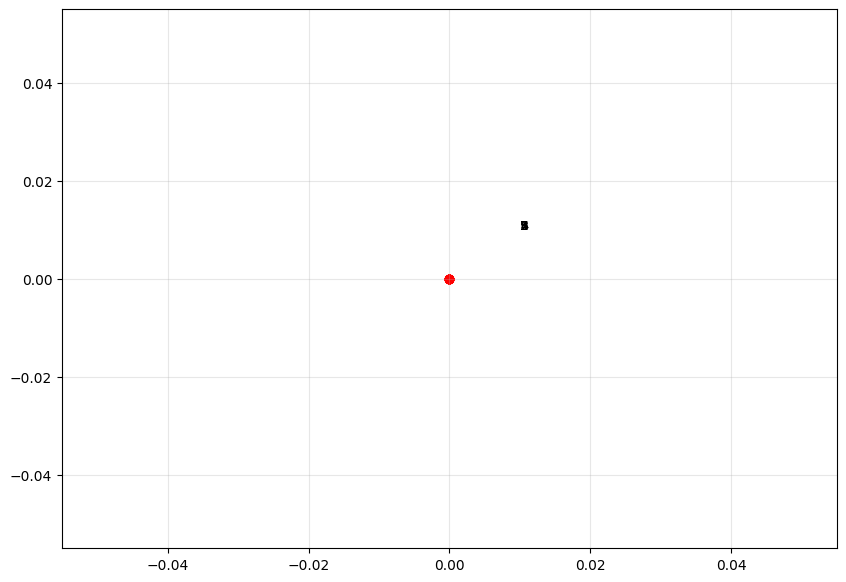

In [ ]:
import matplotlib.pyplot as plt

names = [f"{wins}" for _,wins in Gen]

# 3. Отрисовка
plt.figure(figsize=(10, 7))
plt.scatter(points_2d[:, 0], points_2d[:, 1], c='red')

# Добавляем имена
for i, name in enumerate(names):
    plt.text(points_2d[i, 0] + 0.01, # смещение по X, чтобы текст не наплывал
             points_2d[i, 1] + 0.01, # смещение по Y
             name, 
             fontsize=9)

plt.grid(True, alpha=0.3)
plt.show()

make_decision(self, total, you_have, opponent_have, dice_count, rount_have, comb_list)
comb_list = [(очки, сколько дайсов потрачу)]

In [ ]:
all_found = find_scores(Counter([2, 2, 2, 3, 3, 4]))
comb_list = [(s, 6-d) for _,s,d in all_found]
comb_list.sort(key=lambda x: -x[0])
comb_list

[(200, 3)]

In [ ]:
winner[0].make_decision(4000, 1850, 3250, 6, 0, comb_list)

('skip', 138625.15039265444)

In [ ]:
winner[0].get_w()

array([ 3.96752303, -3.5127723 ,  6.70531119,  1.85151162, -0.56555659,
        4.21498335,  5.08462663, -1.88485462,  1.7660511 ,  6.05223606,
        4.09244048,  4.32908458,  2.41987219, -0.86899988,  0.95976591,
       -0.60112978])

In [ ]:
import json

with open("w.json", "w") as f:
    json.dump(winner[0].get_w().tolist(), f)
